# Esplorare dati tabulari con Pandas

Scopo di queste note è suggerire alcuni usi elementari di [Pandas](https://pandas.pydata.org/), 
per una illustrazione più completa si rimanda al 
[Getting Started](https://pandas.pydata.org/docs/getting_started/intro_tutorials/) ufficiale.

In [1]:
import pandas as pd

## Leggere

Pandas legge non solo file CSV, ma anche HTML, Excel, SQL e molti altri formati. Per esempio, per leggere una tabella da un file HTML (questo contiene i dati dei docenti di UniMI)

In [4]:
docenti = pd.read_html('docenti.html')[0] # 0 è l'indice della tabella da leggere, qui c'è solo la prima

In [6]:
docenti.head(5) # le prime 5 righe

,Fascia,Cognome e Nome,Genere,Facoltà,GSD 2024,SSD 2024,SSD 2015,SC 2015,Struttura di afferenza
0,Ordinario,ABBIATI Giorgio,M,NaN,03/CHEM-05,CHEM-05/A,CHIM/06,03/C1,Scienze farmaceutiche
1,Ordinario,ABBRACCHIO Mariapia,F,NaN,05/BIOS-11,BIOS-11/A,BIO/14,05/G1,Scienze farmaceutiche
2,Ordinario,ABRIGNANI Sergio,M,NaN,06/MEDS-02,MEDS-02/A,MED/04,06/A2,Scienze cliniche e di comunità
3,Associato,ABU AWWAD Amal,F,NaN,12/GIUR-02,GIUR-02/A,IUS/04,12/B1,"Studi internazionali, giuridici e storico-poli..."
4,Associato,ACHILLI Simona,F,NaN,02/PHYS-04,PHYS-04/A,FIS/03,02/B2,"Fisica ""Aldo Pontremoli"""


In [7]:
docenti.columns # i nomi delle colonne

Index(['Fascia', 'Cognome e Nome', 'Genere', 'Facoltà', 'GSD 2024', 'SSD 2024',
       'SSD 2015', 'SC 2015', 'Struttura di afferenza'],
      dtype='str')

In [13]:
# a quanto pare la Facoltà non è presente, eliminiamola

docenti = docenti.drop(columns=['Facoltà'])

In [14]:
docenti['Fascia'].value_counts() # conta i valori unici della colonna Fascia

Fascia
Associato                                                  1141
Ordinario                                                   733
Ricercatore a t.d. - t.pieno (L. 79/2022)                   188
Associato confermato                                        151
Ricercatore                                                 118
Ricercatore a t.d. - t.pieno (art. 24 c.3-a L. 240/10)      107
Ricercatore a t.d. - t.pieno (art. 24 c.3-b L. 240/10)       81
Ricercatore a t.d. - t.defin. (L. 79/2022)                    7
Ricercatore a t.d. - t.defin. (art. 24 c.3-b L. 240/10)       4
Ricercatore a t.d. - t.defin. (art. 24 c.3-a L. 240/10)       4
Straordinario tempo determinato                               1
Name: count, dtype: int64

Semplifichiamo i nomi di fascia, fermandoci al primo spazio

In [15]:
def semplifica_fascia(fascia):
  if 'Straordinario' in fascia: return 'Ordinario'
  return fascia.split()[0]

In [16]:
docenti['Fascia'].apply(semplifica_fascia) # applichiamo a tutte le righe

0       Ordinario
1       Ordinario
2       Ordinario
3       Associato
4       Associato
          ...    
2530    Associato
2531    Associato
2532    Ordinario
2533    Ordinario
2534    Associato
Name: Fascia, Length: 2535, dtype: str

In [12]:
docenti['Fascia Semplificata'] = docenti['Fascia'].apply(semplifica_fascia) # creiamo una nuova colonna con i valori semplificati

Si possono raggruppare i dati, ad esempio per fascia e genere

In [21]:
gruppi = docenti.groupby(['Fascia Semplificata', 'Genere'])

I gruppi (e i valori con cui sono stati costruiti) sono accessibili, e si possono iterare

In [25]:
for nome_gruppo, gruppo in gruppi:
  print(f'Gruppo: {nome_gruppo}, numero di docenti: {len(gruppo)}')

Gruppo: ('Associato', 'F'), numero di docenti: 609
Gruppo: ('Associato', 'M'), numero di docenti: 683
Gruppo: ('Ordinario', 'F'), numero di docenti: 230
Gruppo: ('Ordinario', 'M'), numero di docenti: 504
Gruppo: ('Ricercatore', 'F'), numero di docenti: 275
Gruppo: ('Ricercatore', 'M'), numero di docenti: 234


Talvota è però più pratico usare funzioni di aggregazione, ad esempio per contare il numero di docenti per fascia e genere

In [31]:
per_fascia_e_genere = docenti.groupby(['Fascia Semplificata', 'Genere']).size()
per_fascia_e_genere 

Fascia Semplificata  Genere
Associato            F         609
                     M         683
Ordinario            F         230
                     M         504
Ricercatore          F         275
                     M         234
dtype: int64

In [32]:
# per facilitare la lettura possiamo trasformare il doppio indice sulle righe in un indice
# per righe e colonne

per_fascia_e_genere.unstack() 

Genere,F,M
Fascia Semplificata,,
Associato,609,683
Ordinario,230,504
Ricercatore,275,234


In [39]:
# e riordinare le righe

riordinato = per_fascia_e_genere.unstack().reindex(['Ricercatore', 'Associato', 'Ordinario'])
riordinato

Genere,F,M
Fascia Semplificata,,
Ricercatore,275,234
Associato,609,683
Ordinario,230,504


<Axes: xlabel='Fascia Semplificata'>

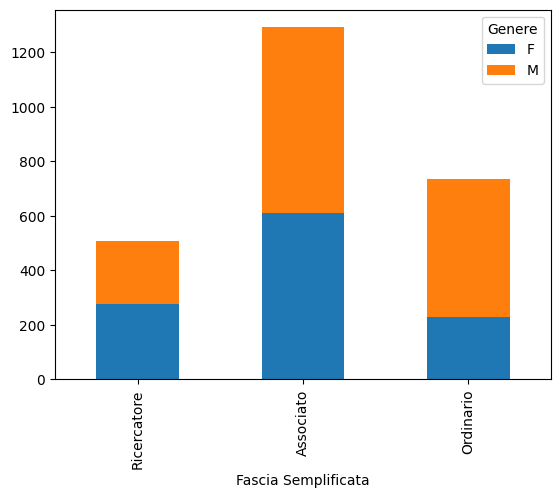

In [41]:
# possiamo persino fare un grafico, che mostra evidentemente che ci sono più uomini 
# che donne in tutte le fasce, e che la fascia con maggior disparità è quella degli ordinari

riordinato.plot(kind='bar', stacked=True)

In [ ]:
# trascurando la fascia, badando al SSD e al genere...

per_genere_e_ssd = docenti.groupby(['Genere', 'SSD 2024']).size().unstack(0, fill_value=0)
per_genere_e_ssd

Genere,F,M
SSD 2024,,
AGRI-01/A,9,12
AGRI-02/A,2,7
AGRI-02/B,1,1
AGRI-03/A,2,6
AGRI-03/B,0,3
...,...,...
STAN-01/B,2,2
STAT-01/A,7,3
STAT-03/A,1,0


In [67]:
# gli informatici sono i più discriminatori, con 50 maschi più che femmine

(per_genere_e_ssd['M'] - per_genere_e_ssd['F']).sort_values( ascending=False).head(10)

SSD 2024
INFO-01/A    51
MEDS-16/A    18
MEDF-01/B    16
PHYS-04/A    16
ECON-01/A    15
PHYS-03/A    15
GSPS-02/A    13
MEDS-06/A    13
PHYS-01/A    13
PHYS-02/A    12
dtype: int64